# Accessing and comparing ASPCAP model spectra

## Learning Goals
By the end of this tutorial, you will:
- Understand how to retrieve SDSS data with sdss-access
- Understand some of the structure of a fits file containing ASPCAP model spectra
- Be able to compare ASPCAP model spectra

## Introduction
The Apache Point Observatory Galactic Evolution Experiment (APOGEE) is an infrared spectroscopic survey using two spectrographs at the two SDSS V observatories, Apache Point Observatory (APO) and Las Campanas Observatory (LCO).

In this short tutorial we will demonstrate how to use the sdss-access tool to retreive the ASPCAP model spectra of that star from the SDSS Science Archive Server (SAS). Then we will retreive various model spectra from the file and plot them for comparison.

## Imports
This tutorial requires two commonly used python packages, and an SDSS specific package
- _matplotlib_ for plotting
- _astropy_ for reading fits table
- _sdss-access_ for accessing data on the SAS
- _numpy_ for doing array math

Missing packages can be installed via `pip install matplotlib astropy sdss-access` 

NOTE: You may want to set the `$SAS_BASE_DIR` environment variable before starting this notebook, other wise `$HOME/sas` will be created and used

In [1]:
import matplotlib.pyplot as plt
from astropy.table import Table
import numpy as np

from sdss_access import Access
access = Access(release='dr20')

import warnings

warnings.simplefilter("ignore")

Other tutorials give examples of using the astra allStar files to find ID numbers and other information. Since we're only interested in accessing spectra, we'll skip loading that large file for now and simply assume we know an sdss_id.

In [2]:
sdss_id = 94846885

## sdss-access

sdss-access has extensive [documentation](https://sdss-access.readthedocs.io/en/latest/), but we should mention a few things. First if you are a member of the collaboration accessing proprietary data, you need to set up a [.netrc file](https://sdss-access.readthedocs.io/en/latest/auth.html). After that usage is the same for everyone.

You need specify the file species you need, in this case 'mwmStar', then a series of key word arguments that vary depending on the file species. A list of file species and their keyword arugments is [available](https://sdss-access.readthedocs.io/en/latest/paths.html).

The code block below showa an example of retreiving an sdss spectrum. First we construct the SAS file path with `access.full`, then we check to see if the file exists. If you are running this notebook on SciServer, or another system with a full copy of the SAS, or if you have downloaded this specific file before, we can skip downloading the data. Otherwise, `access.commit()` will retrieve the file and save it to your local SAS, `$SAS_BASE_DIR`, with the same structure as the SAS (so it will be many files deep). Note: it is important to skip the download step if the file already exists locally. Attempting to download a file that already exists can cause errors on some systems.

In [3]:
aspcapStar_filename = access.full('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
if not access.exists('',full=aspcapStar_filename):
    access.remote()
    access.add('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
    access.set_stream()
    access.commit()

print(access.exists('', full=aspcapStar_filename))

mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
if not access.exists('',full=mwmStar_filename):
    access.remote()
    access.add('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    access.set_stream()
    access.commit()
    mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)

print(access.exists('', full=mwmStar_filename))

True
True


## Load the spectrum

Now using `astropy.Table` load the data. HDU 3 contains the APO spectrum.

In [4]:
aspcapStar = Table.read(aspcapStar_filename, hdu=3)
aspcapStar

star_pk,release,filetype,apred,apstar,obj,telescope,healpix,field,prefix,min_mjd,max_mjd,n_entries,n_visits,n_good_visits,n_good_rvs,mean_fiber,std_fiber,spectrum_flags,v_rad,e_v_rad,std_v_rad,median_e_v_rad,doppler_teff,doppler_e_teff,doppler_logg,doppler_e_logg,doppler_fe_h,doppler_e_fe_h,doppler_rchi2,doppler_flags,xcorr_v_rad,xcorr_v_rel,xcorr_e_v_rel,ccfwhm,autofwhm,n_components,spectrum_pk_id,task_pk,v_astra,created,t_elapsed,t_overhead,tag,wavelength,model_flux,continuum,model_flux_al_h,model_flux_c_12_13,model_flux_ca_h,model_flux_ce_h,model_flux_c_1_h,model_flux_c_h,model_flux_co_h,model_flux_cr_h,model_flux_cu_h,model_flux_fe_h,model_flux_k_h,model_flux_mg_h,model_flux_mn_h,model_flux_na_h,model_flux_nd_h,model_flux_ni_h,model_flux_n_h,model_flux_o_h,model_flux_p_h,model_flux_si_h,model_flux_s_h,model_flux_ti_h,model_flux_ti_2_h,model_flux_v_h,irfm_teff,irfm_teff_flags,teff,e_teff,logg,e_logg,v_micro,e_v_micro,v_sini,e_v_sini,m_h_atm,e_m_h_atm,alpha_m_atm,e_alpha_m_atm,c_m_atm,e_c_m_atm,n_m_atm,e_n_m_atm,al_h,e_al_h,al_h_flags,al_h_rchi2,c_12_13,e_c_12_13,c_12_13_flags,c_12_13_rchi2,ca_h,e_ca_h,ca_h_flags,ca_h_rchi2,ce_h,e_ce_h,ce_h_flags,ce_h_rchi2,c_1_h,e_c_1_h,c_1_h_flags,c_1_h_rchi2,c_h,e_c_h,c_h_flags,c_h_rchi2,co_h,e_co_h,co_h_flags,co_h_rchi2,cr_h,e_cr_h,cr_h_flags,cr_h_rchi2,cu_h,e_cu_h,cu_h_flags,cu_h_rchi2,fe_h,e_fe_h,fe_h_flags,fe_h_rchi2,k_h,e_k_h,k_h_flags,k_h_rchi2,mg_h,e_mg_h,mg_h_flags,mg_h_rchi2,mn_h,e_mn_h,mn_h_flags,mn_h_rchi2,na_h,e_na_h,na_h_flags,na_h_rchi2,nd_h,e_nd_h,nd_h_flags,nd_h_rchi2,ni_h,e_ni_h,ni_h_flags,ni_h_rchi2,n_h,e_n_h,n_h_flags,n_h_rchi2,o_h,e_o_h,o_h_flags,o_h_rchi2,p_h,e_p_h,p_h_flags,p_h_rchi2,si_h,e_si_h,si_h_flags,si_h_rchi2,s_h,e_s_h,s_h_flags,s_h_rchi2,ti_h,e_ti_h,ti_h_flags,ti_h_rchi2,ti_2_h,e_ti_2_h,ti_2_h_flags,ti_2_h_rchi2,v_h,e_v_h,v_h_flags,v_h_rchi2,short_grid_name,continuum_order,continuum_reject,interpolation_order,initial_flags,snr,rchi2,ferre_log_snr_sq,ferre_time_elapsed,result_flags,stellar_parameters_task_pk_id,al_h_task_pk_id,c_12_13_task_pk_id,ca_h_task_pk_id,ce_h_task_pk_id,c_1_h_task_pk_id,c_h_task_pk_id,co_h_task_pk_id,cr_h_task_pk_id,cu_h_task_pk_id,fe_h_task_pk_id,k_h_task_pk_id,mg_h_task_pk_id,mn_h_task_pk_id,na_h_task_pk_id,nd_h_task_pk_id,ni_h_task_pk_id,n_h_task_pk_id,o_h_task_pk_id,p_h_task_pk_id,si_h_task_pk_id,s_h_task_pk_id,ti_h_task_pk_id,ti_2_h_task_pk_id,v_h_task_pk_id,calibrated_flags,mass,radius,raw_teff,raw_e_teff,raw_logg,raw_e_logg,raw_v_micro,raw_e_v_micro,raw_v_sini,raw_e_v_sini,raw_m_h_atm,raw_e_m_h_atm,raw_alpha_m_atm,raw_e_alpha_m_atm,raw_c_m_atm,raw_e_c_m_atm,raw_n_m_atm,raw_e_n_m_atm,raw_al_h,raw_e_al_h,raw_c_12_13,raw_e_c_12_13,raw_ca_h,raw_e_ca_h,raw_ce_h,raw_e_ce_h,raw_c_1_h,raw_e_c_1_h,raw_c_h,raw_e_c_h,raw_co_h,raw_e_co_h,raw_cr_h,raw_e_cr_h,raw_cu_h,raw_e_cu_h,raw_fe_h,raw_e_fe_h,raw_k_h,raw_e_k_h,raw_mg_h,raw_e_mg_h,raw_mn_h,raw_e_mn_h,raw_na_h,raw_e_na_h,raw_nd_h,raw_e_nd_h,raw_ni_h,raw_e_ni_h,raw_n_h,raw_e_n_h,raw_o_h,raw_e_o_h,raw_p_h,raw_e_p_h,raw_si_h,raw_e_si_h,raw_s_h,raw_e_s_h,raw_ti_h,raw_e_ti_h,raw_ti_2_h,raw_e_ti_2_h,raw_v_h,raw_e_v_h
int64,bytes4,bytes6,bytes4,bytes5,bytes18,bytes6,int32,bytes10,bytes2,int32,int32,int32,int32,int32,int32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,int32,int64,int64,bytes5,bytes26,float32,float32,bytes1,float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,int64,floa

We then extract wavelength and the "best fit" model flux to more convenient variables. We can see there are multiple co-added spectra for this star, we'll arbitrarily pick the first spectra for now, hence `[0]`.

We'll also grab the best fit spectrum for magnesium (Mg) since this is generally a well determined element in APOGEE.

In [5]:
wavelength = aspcapStar["wavelength"][0]
model = aspcapStar["model_flux"][0]
continuum = aspcapStar["continuum"][0]
mg_model = aspcapStar["model_flux_mg_h"][0]

Now plot the spectrum, flux vs wavelength.

Text(0, 0.5, 'flux')

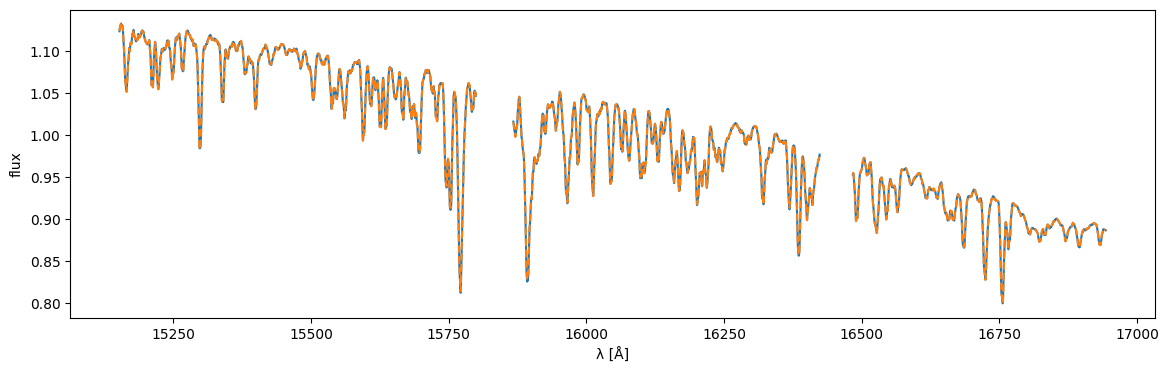

In [6]:
plt.figure(figsize=(14,4))

plt.plot(wavelength, model)
plt.plot(wavelength, mg_model, linestyle="--")
plt.xlabel("λ [Å]")
plt.ylabel("flux")

From this plot, we can see both that the final model flux is in good agreement with the Mg model flux, and based on the units, we can see the model flux arrays are stored in some continuum normalized units.

To compare the model to the observed spectrum, we can use the continuum array provided.

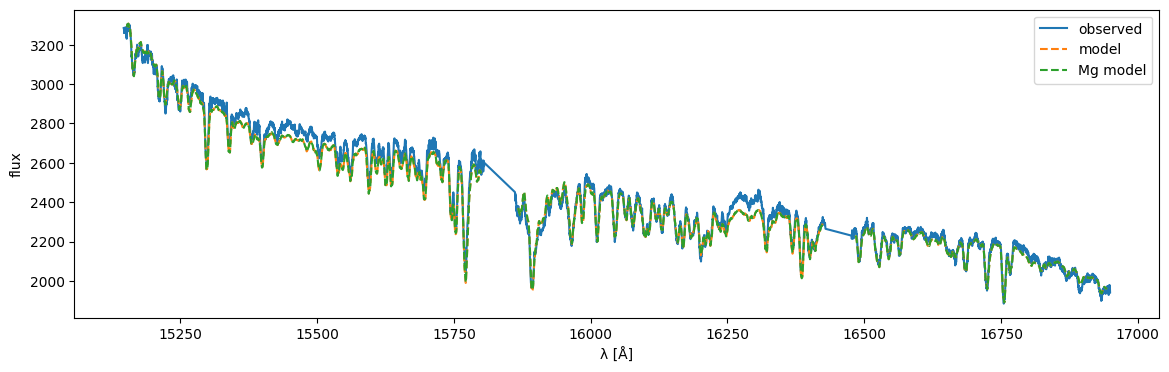

In [7]:
mwmStar = Table.read(mwmStar_filename, hdu=3)

obs_wl = mwmStar["wavelength"][0]
obs_flux = mwmStar["flux"][0]
obs_err = mwmStar["ivar"][0]**(-0.5)

mask = obs_err < 0.1 * obs_flux

plt.figure(figsize=(14,4))

plt.plot(obs_wl[mask], obs_flux[mask], label="observed")
plt.plot(wavelength, model*continuum, linestyle="--", label="model")
plt.plot(wavelength, mg_model*continuum, linestyle="--", label="Mg model")
plt.xlabel("λ [Å]")
plt.ylabel("flux")
plt.legend()

This process can be repeated for any element measured by ASPCAP (see e.g. the [datamodel](https://data.sdss.org/datamodel/files/MWM_ASTRA/V_ASTRA/results/star/SDSS_ID_GROUPS/astraStarASPCAP.html), or [Jönsson et al. 2020](https://ui.adsabs.harvard.edu/abs/2020AJ....160..120J/abstract)).

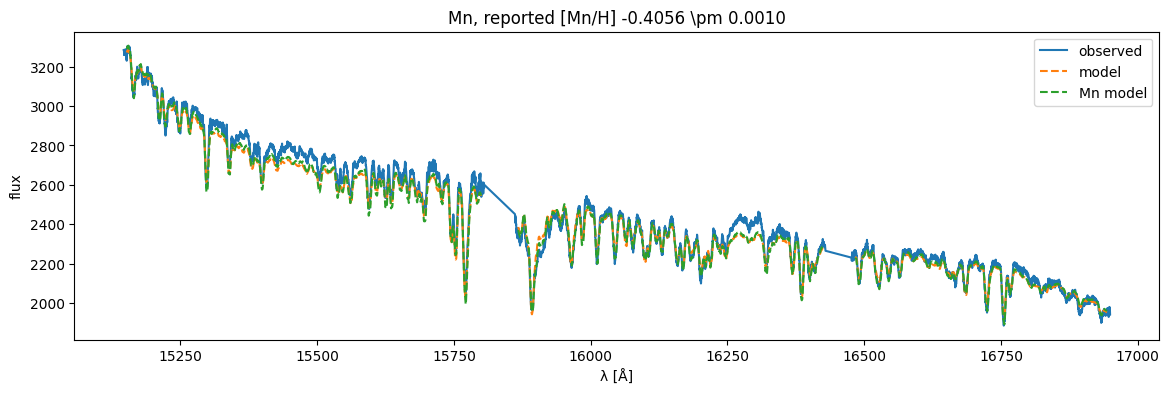

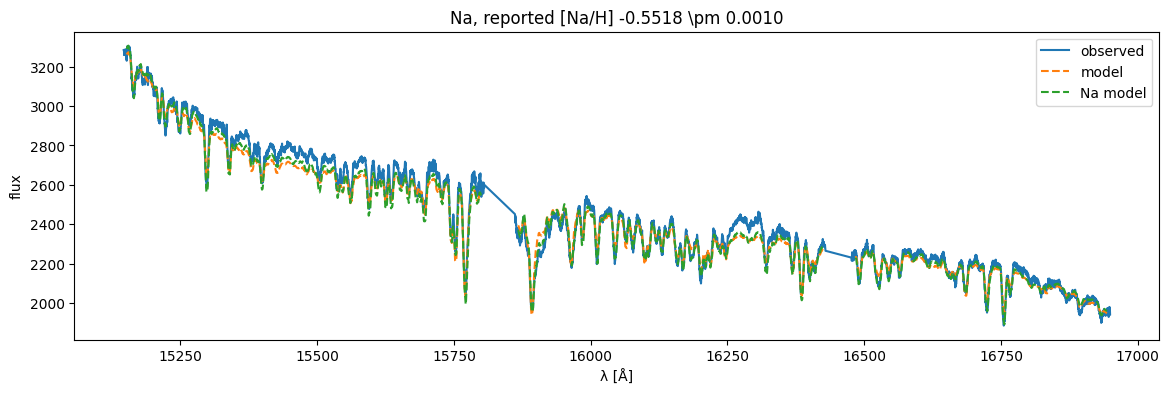

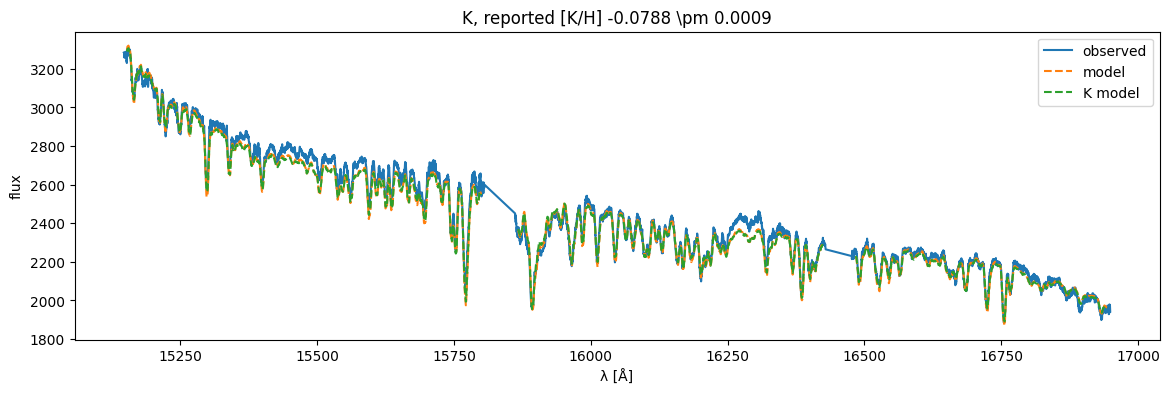

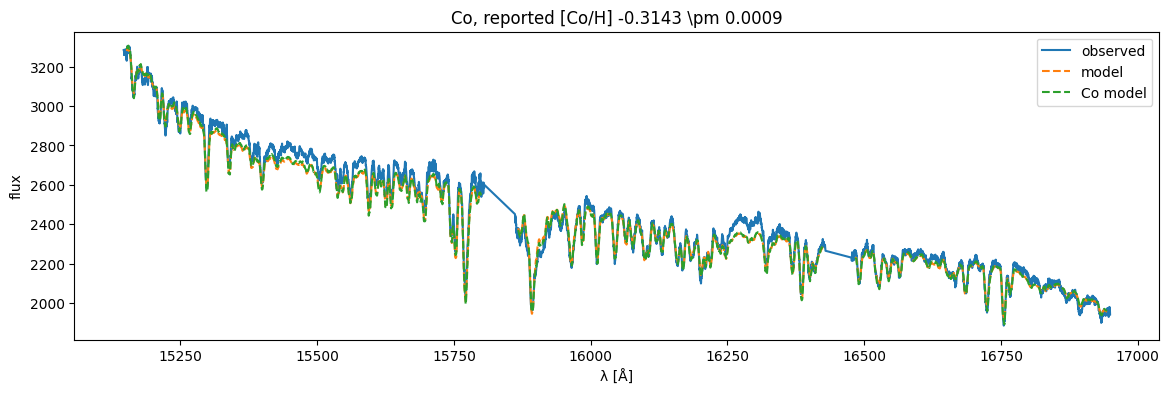

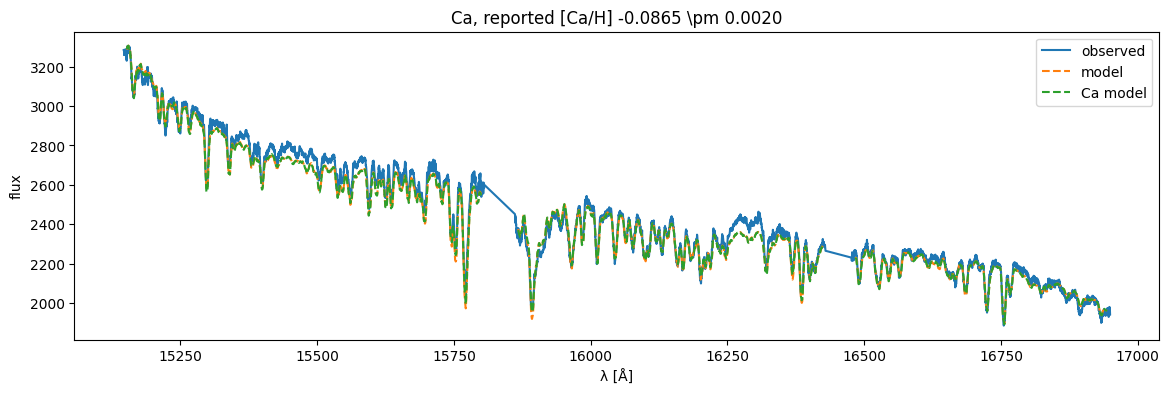

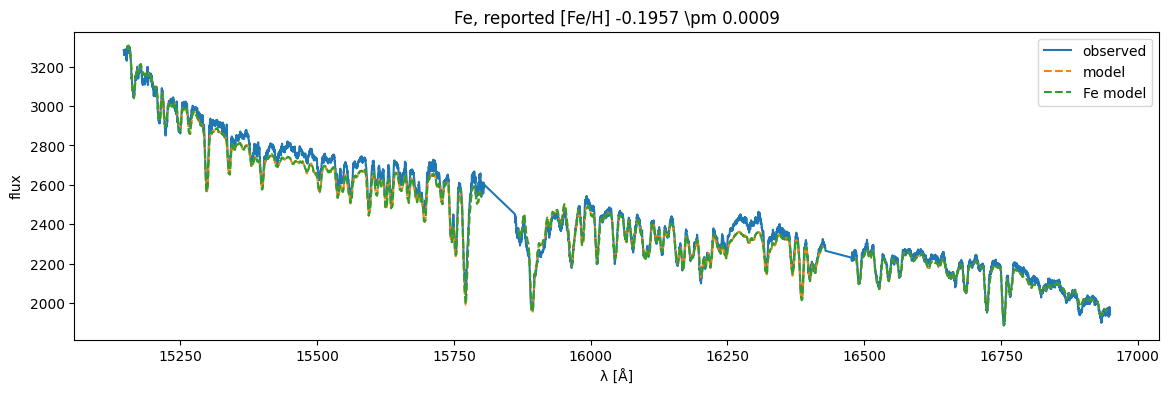

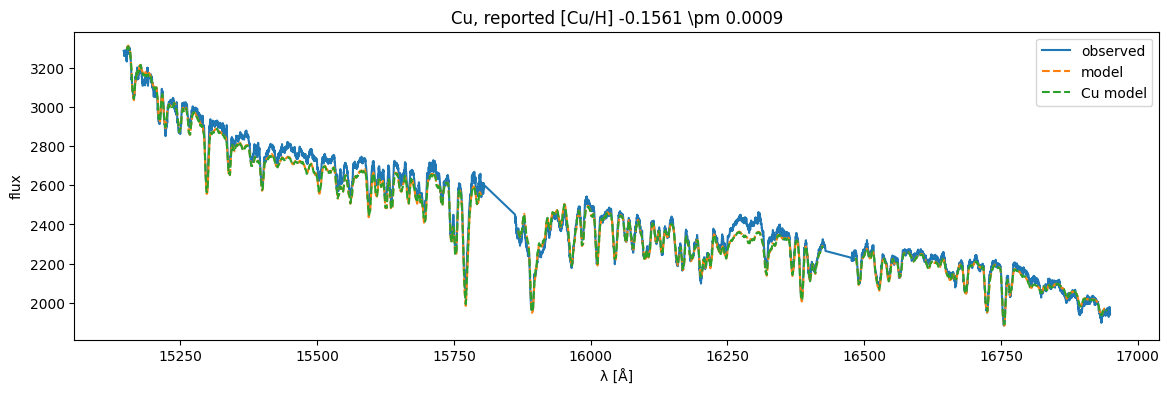

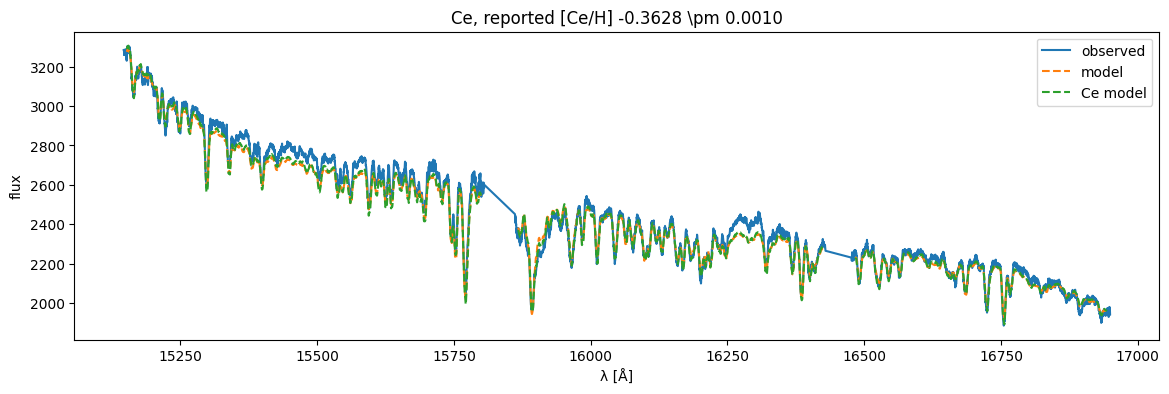

In [8]:
elems = ["mn", "na", "k", "co", "ca", "fe", "cu", "ce"]

for elem in elems:
    model = aspcapStar[f"model_flux_{elem}_h"][0]
    plt.figure(figsize=(14,4))

    plt.title(fr"{elem.title()}, reported [{elem.title()}/H] {aspcapStar[f'{elem}_h'][0]:.4f} \pm {aspcapStar[f'e_{elem}_h'][0]:.4f}")

    plt.plot(obs_wl[mask], obs_flux[mask], label="observed")
    plt.plot(wavelength, model*continuum, linestyle="--", label="model")
    plt.plot(wavelength, mg_model*continuum, linestyle="--", label=f"{elem.title()} model")
    plt.xlabel("λ [Å]")
    plt.ylabel("flux")
    plt.legend()

These relatively "zoomed out" plots hide a lot of detail in the APOGEE spectra. Another SDSS tutorial delves deeper into APOGEE spectra with "zoomed in" plots showing individual lines. Combining these models and that level of detail is left as an exercise for the reader.

### About this notebook

This notebook was created to give an example of using the `sdss-access` tool, and illustrate how to access ASPCAP model spectra.

**Authors**: John Donor

**Last Update**: 2026 Apr 13

If you use `astropy`  for published research, please cite the
authors. Follow this link for more information about citing `astropy`:

* [Citing `astropy`](https://www.astropy.org/acknowledging.html)

And of course please [cite](https://sdss.org/collaboration/citing-sdss/) SDSS when you use our data.